# ARTI 404 – Image Processing
## Lab 4: Intensity Transformations and Filtering – Spatial Domain

**College of Computer Science and Information Technology – Department of Computer Engineering**
**Imam Abdulrahman Bin Faisal University – 2025/2026**

| | |
|---|---|
| **Student Name** | Nawaf Alghamdi |
| **Student ID** | 2240007352|

**Session outcome (Outcome #2):** Write a program that implements fundamental image processing algorithms.

**Contents**
1. **Procedural tasks**
   - Task 1 – Thresholding with fixed threshold values (Parrot image)
   - Task 2 – Histogram processing: contrast stretching between the 2nd and 98th percentiles (moon image)
2. **Assessment tasks**
   - Task 1 – Contrast stretching between the 3rd and 80th percentiles + histogram
   - Task 2 – Histogram equalization with `exposure.equalize_hist` + histogram
   - Task 3 – Histogram matching: Chelsea image matched to the rocket image (reference)

## 0. Setup
Libraries used: OpenCV, NumPy, Pillow, scikit-image and Matplotlib.
Input images are kept in the `images/` folder and every figure produced by this notebook is saved in the `outputs/` folder.

In [1]:
import os
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import skimage
from PIL import Image
from skimage import data, img_as_float, img_as_ubyte
from skimage import exposure

IMG_DIR = 'images'    # input images used in this lab
OUT_DIR = 'outputs'   # figures produced by this notebook
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

print('OpenCV      :', cv2.__version__)
print('NumPy       :', np.__version__)
print('scikit-image:', skimage.__version__)
print('Matplotlib  :', matplotlib.__version__)

OpenCV      : 5.0.0
NumPy       : 2.5.3
scikit-image: 0.26.0
Matplotlib  : 3.11.2


The moon, rocket and Chelsea images come from `skimage.data`. A copy of each is saved to `images/` so the
submission folder contains every image used in this lab (the Parrot image is already in `images/Parrot.png`).

In [2]:
samples = {'moon.png': data.moon(), 'rocket.png': data.rocket(), 'chelsea.png': data.chelsea()}
for name, im in samples.items():
    Image.fromarray(im).save(os.path.join(IMG_DIR, name))
    print(f'saved images/{name:12s} shape={im.shape}, dtype={im.dtype}')

print('images folder:', sorted(os.listdir(IMG_DIR)))

saved images/moon.png     shape=(512, 512), dtype=uint8
saved images/rocket.png   shape=(427, 640, 3), dtype=uint8


saved images/chelsea.png  shape=(300, 451, 3), dtype=uint8
images folder: ['Parrot.png', 'chelsea.png', 'moon.png', 'rocket.png']


---
# Part A – Procedural Tasks

## Task 1: Thresholding
### Step 1: Apply thresholding with a fixed threshold on an image

Thresholding converts a grayscale image into a **binary** image. With `cv2.THRESH_BINARY`, every pixel whose
intensity is **greater than** the threshold *T* becomes white (255, foreground) and every other pixel becomes
black (0, background):

$$ g(x,y) = \begin{cases} 255 & f(x,y) > T \\ 0 & f(x,y) \le T \end{cases} $$

The image is thresholded with *T* = 0, 50, 100, 150 and 200.

> **Note:** the manual's code displays results with `cv2.imshow()`, which opens separate desktop windows and does
> not keep the result inside the notebook. The same OpenCV thresholding code is used below, but the images are shown
> with Matplotlib so the outputs stay visible in the notebook and can be included in the report.

In [3]:
# Load the image in grayscale
img = cv2.imread(os.path.join(IMG_DIR, 'Parrot.png'), cv2.IMREAD_GRAYSCALE)
assert img is not None, 'Parrot.png was not found in the images folder'
print('Parrot (grayscale):', img.shape, img.dtype, '| min =', img.min(), '| max =', img.max(),
      '| mean = %.1f' % img.mean())

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
thresholded = []
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    thresholded.append((threshold_value, thresh))
    white = 100 * np.count_nonzero(thresh) / thresh.size
    print(f'T = {threshold_value:3d}  ->  {white:5.1f}% of the pixels are white (foreground)')

Parrot (grayscale): (340, 453) uint8 | min = 0 | max = 252 | mean = 117.8
T =   0  ->  100.0% of the pixels are white (foreground)
T =  50  ->   99.1% of the pixels are white (foreground)
T = 100  ->   62.9% of the pixels are white (foreground)
T = 150  ->   19.0% of the pixels are white (foreground)
T = 200  ->    3.0% of the pixels are white (foreground)


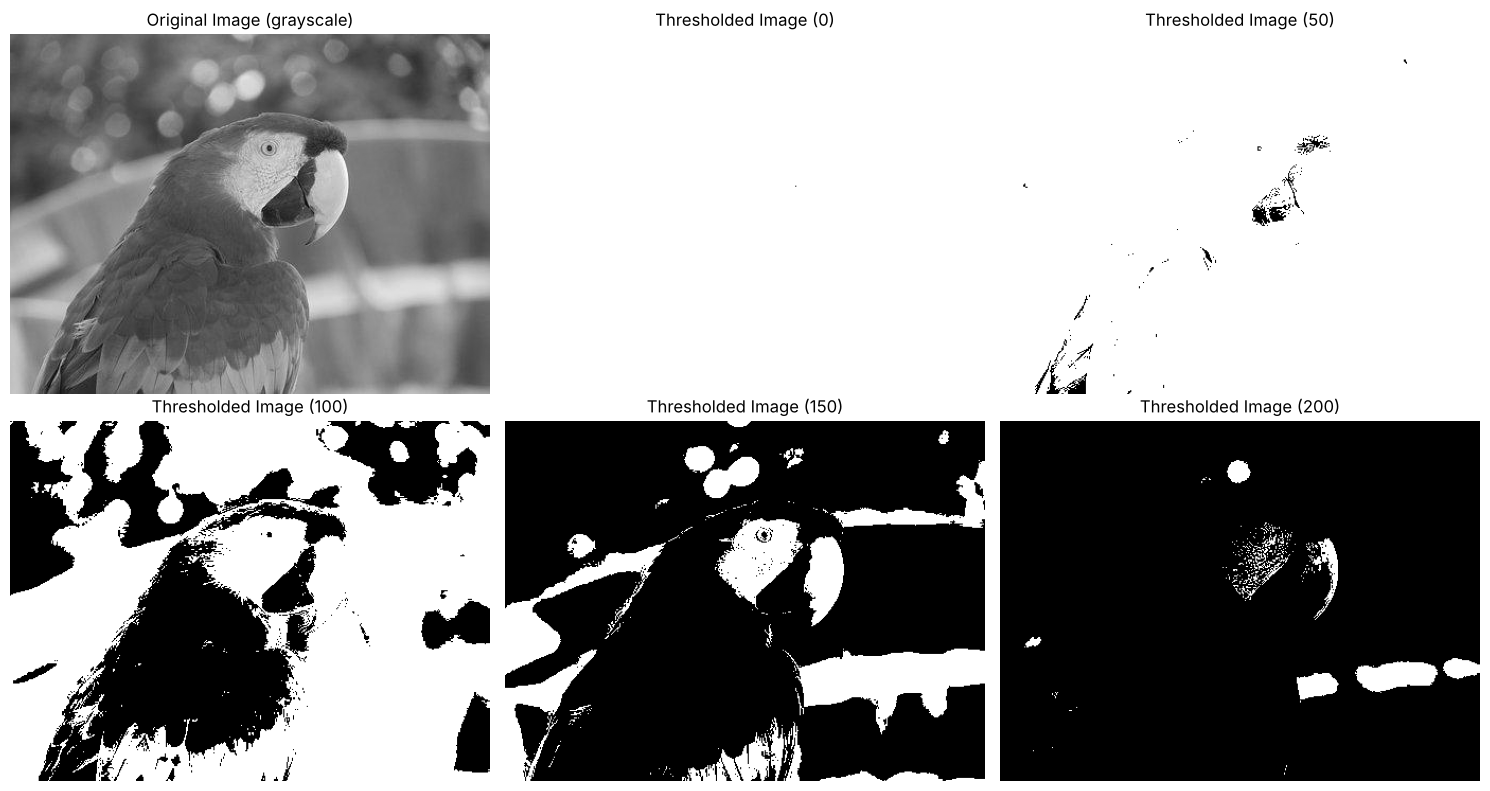

In [4]:
# Display the original image and the thresholded images
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image (grayscale)')
for ax, (t, th) in zip(axes[1:], thresholded):
    ax.imshow(th, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'Thresholded Image ({t})')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'A1_thresholding.png'), dpi=110, bbox_inches='tight')
plt.show()

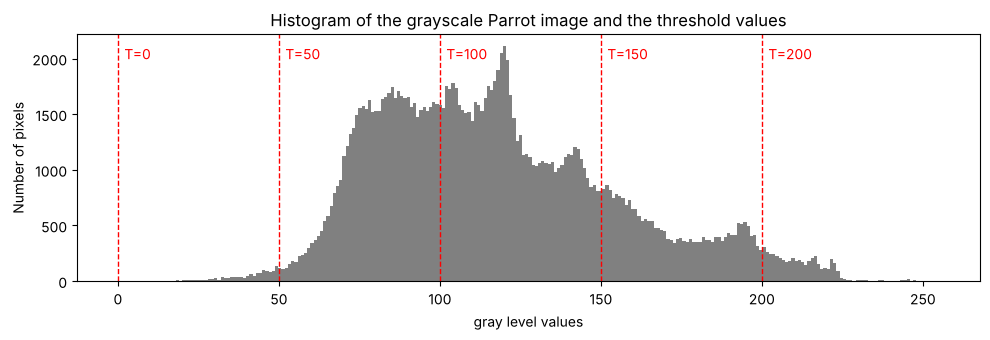

In [5]:
# Histogram of the grayscale Parrot image with the five threshold values marked
plt.figure(figsize=(10, 3.5))
plt.hist(img.ravel(), bins=256, range=(0, 255), color='gray')
for t in threshold_values:
    plt.axvline(t, color='red', linestyle='--', linewidth=1)
    plt.text(t + 2, plt.ylim()[1] * 0.9, f'T={t}', color='red')
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.title('Histogram of the grayscale Parrot image and the threshold values')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'A1_parrot_histogram.png'), dpi=110, bbox_inches='tight')
plt.show()

### Observations – Task 1 (Thresholding)
- The grayscale Parrot image has intensities between 0 and 252 (mean ≈ 118); most pixels lie between about 60 and 225 (see the histogram above).
- **T = 0:** practically every pixel is greater than 0, so the output is completely white (100 %). No separation is achieved.
- **T = 50:** still 99.1 % white. Only the darkest pixels (the black part of the beak, the eye and a few shadowed feathers) become black.
- **T = 100:** 62.9 % white. The threshold falls in the middle of the main histogram peak: the red body of the parrot (dark in grayscale) becomes black while most of the green background becomes white, and the result is noisy.
- **T = 150:** 19.0 % white. Only the bright regions remain: the white face patch, the beak and the bright highlights/leaves in the background.
- **T = 200:** only 3.0 % white – just the brightest highlights (part of the face patch, the edge of the beak and a few background highlights).
- **Conclusion:** increasing *T* reduces the number of foreground (white) pixels. The result depends strongly on the chosen threshold; for this image no single global threshold separates the parrot from the background cleanly, because the parrot and the background share overlapping gray levels. This is why automatic (Otsu) or adaptive thresholding is often preferred.

## Task 2: Histogram Processing
### Step 1: Load necessary libraries

In [6]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_float
from skimage import exposure

### Step 2: Load the moon image

In [7]:
img = data.moon()
print('moon image:', img.shape, img.dtype, '| min =', img.min(), '| max =', img.max(),
      '| mean = %.1f' % img.mean(), '| std = %.1f' % img.std())

moon image: (512, 512) uint8 | min = 0 | max = 255 | mean = 112.2 | std = 13.3


### Step 3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles

**Contrast stretching** maps the input range $[p_{low}, p_{high}]$ linearly onto the full range $[0, 255]$:

$$ s = 255 \cdot \frac{r - p_{low}}{p_{high} - p_{low}} $$

and clips values below $p_{low}$ to 0 and above $p_{high}$ to 255.

In [8]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

print(f'2nd percentile = {p2:.0f}, 98th percentile = {p98:.0f}')
print(f'Range before: [{img.min()}, {img.max()}]  ->  after: [{img_rescale.min()}, {img_rescale.max()}]')
print(f'std before = {img.std():.1f}, std after = {img_rescale.std():.1f}')
print(f'distinct gray levels: {len(np.unique(img))} -> {len(np.unique(img_rescale))}')

2nd percentile = 78, 98th percentile = 129
Range before: [0, 255]  ->  after: [0, 255]
std before = 13.3, std after = 42.3
distinct gray levels: 178 -> 52


### Step 4: Display the image with its histogram of (Step 2) and (Step 3)

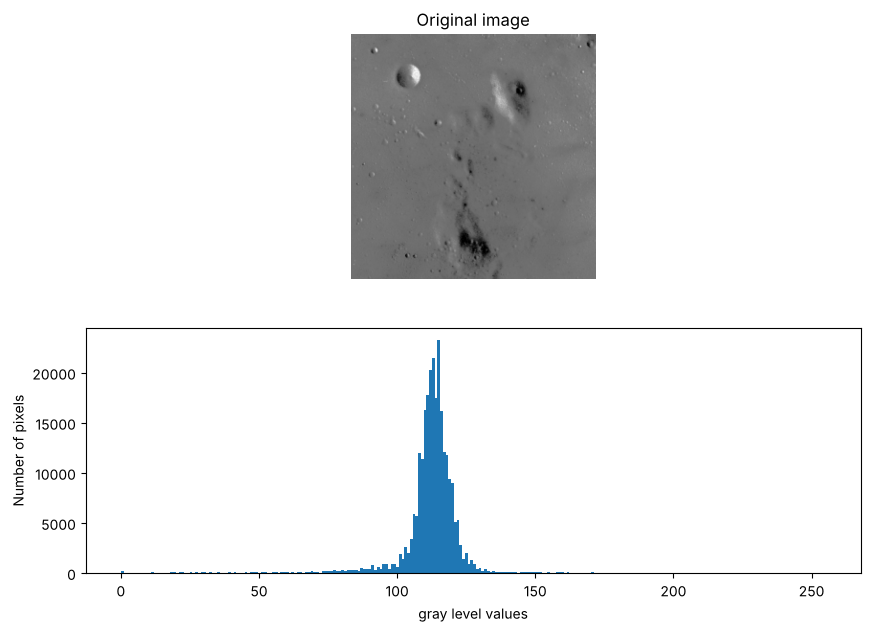

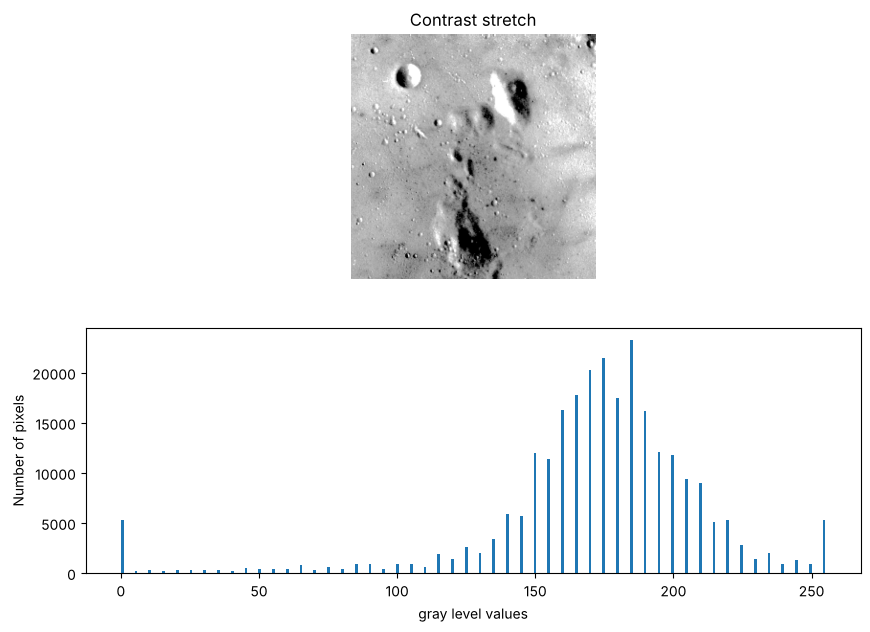

In [9]:
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.savefig(os.path.join(OUT_DIR, 'A2_moon_original.png'), dpi=110, bbox_inches='tight')
plt.show()

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.savefig(os.path.join(OUT_DIR, 'A2_moon_contrast_stretch_2_98.png'), dpi=110, bbox_inches='tight')
plt.show()

### Observations – Task 2 (Histogram processing / contrast stretching)
- The original moon image has **low contrast**: although its minimum and maximum are 0 and 255, almost all pixels are concentrated in a narrow band around 112 (2nd–98th percentiles = 78–129, standard deviation = 13.3). The image looks flat and grey.
- Stretching the range [78, 129] onto [0, 255] spreads the histogram over the full gray-level range; the standard deviation rises from 13.3 to 42.3 and the craters and ridges become clearly visible.
- Only about 2 % of the pixels at each end are clipped to 0 or 255 (the small spikes at both ends of the histogram), so very little information is lost.
- The stretched histogram has a **comb shape** (gaps between bars): contrast stretching is a linear point operation, so it cannot create new gray levels – the 52 remaining levels are only spread further apart (178 → 52 distinct levels, because the clipped tails merge into 0 and 255).

---
# Part B – Assessment Tasks

## Assessment Task 1: Contrast stretching with the 3rd and 80th percentiles
Using the same moon image, rescale the intensity values to include all intensities that fall within the
**3rd and 80th percentiles**, and plot the histogram.

3rd percentile = 87, 80th percentile = 118
Pixels mapped to 0   (value <= 87):   3.1%
Pixels mapped to 255 (value >= 118):  21.0%
mean: 112.2 -> 203.7 | std: 13.3 -> 55.5
distinct gray levels: 178 -> 32


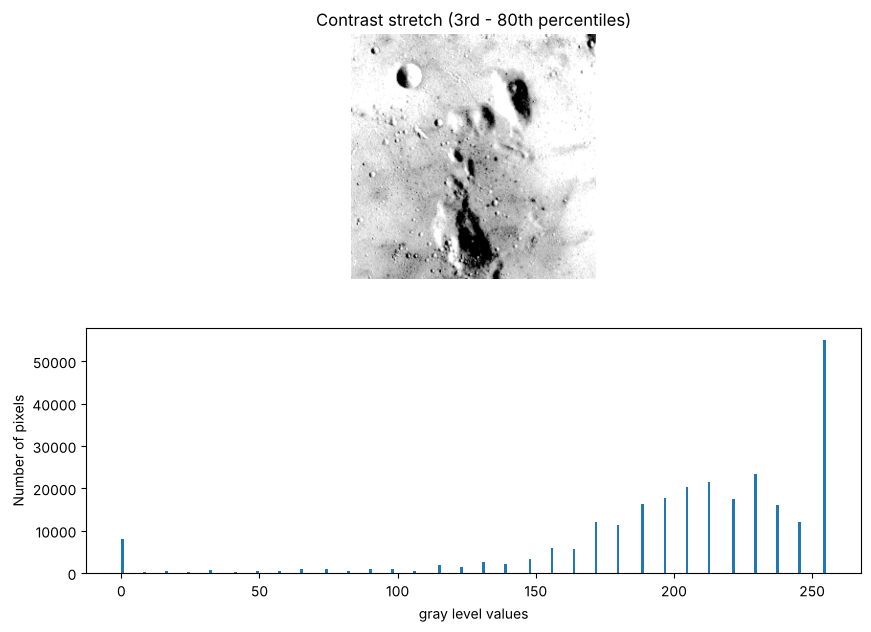

In [10]:
# Contrast stretching between the 3rd and 80th percentiles
p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))

print(f'3rd percentile = {p3:.0f}, 80th percentile = {p80:.0f}')
print(f'Pixels mapped to 0   (value <= {p3:.0f}): {100 * np.mean(img <= p3):5.1f}%')
print(f'Pixels mapped to 255 (value >= {p80:.0f}): {100 * np.mean(img >= p80):5.1f}%')
print(f'mean: {img.mean():.1f} -> {img_rescale_3_80.mean():.1f} | std: {img.std():.1f} -> {img_rescale_3_80.std():.1f}')
print(f'distinct gray levels: {len(np.unique(img))} -> {len(np.unique(img_rescale_3_80))}')

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd - 80th percentiles)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.savefig(os.path.join(OUT_DIR, 'B1_contrast_stretch_3_80.png'), dpi=110, bbox_inches='tight')
plt.show()

**Comparison:** original vs. 2nd–98th percentile stretch vs. 3rd–80th percentile stretch.

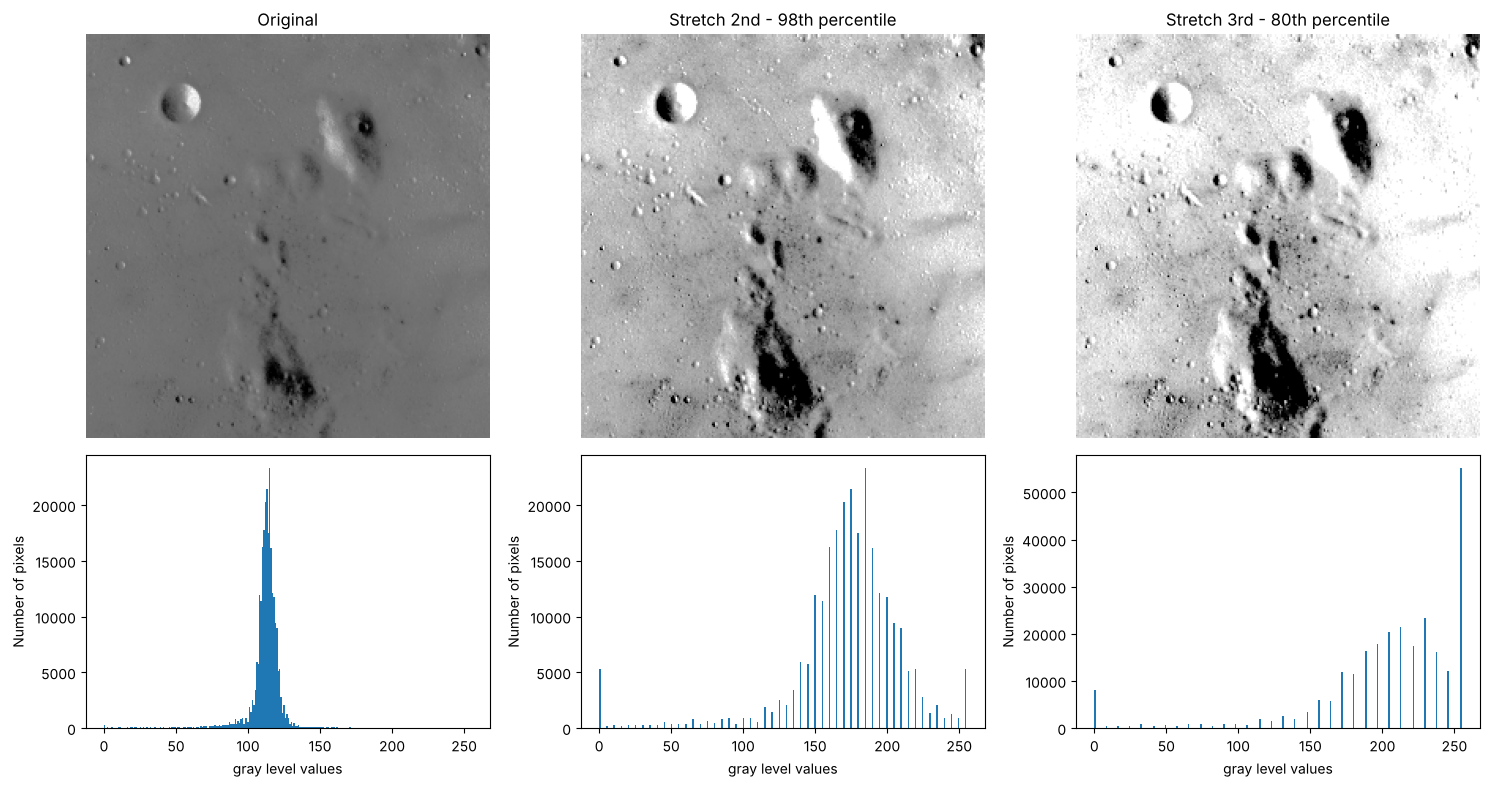

In [11]:
versions = [(img, 'Original'),
            (img_rescale, 'Stretch 2nd - 98th percentile'),
            (img_rescale_3_80, 'Stretch 3rd - 80th percentile')]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), gridspec_kw={'height_ratios': [3, 2]})
for i, (im, title) in enumerate(versions):
    axes[0, i].imshow(im, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(title)
    axes[0, i].axis('off')
    axes[1, i].hist(im.flat, bins=256, range=(0, 255))
    axes[1, i].set_xlabel('gray level values')
    axes[1, i].set_ylabel('Number of pixels')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'B1_comparison.png'), dpi=110, bbox_inches='tight')
plt.show()

### Observations – Assessment Task 1 (3rd–80th percentiles)
- The 3rd and 80th percentiles are **87 and 118**. This input range is narrower than before (31 levels instead of 51) and is **asymmetric**: only 3.1 % of the pixels are clipped to 0, but **21.0 %** of the pixels (every pixel ≥ 118) are clipped to 255. This produces the very large spike at 255 in the histogram (≈ 55,000 pixels).
- The dark and mid tones receive a stronger stretch (standard deviation 13.3 → 55.5), so the shadows of the craters and the dark regions stand out more than with the 2nd–98th stretch.
- However, the image becomes much brighter (mean 112 → 204) and the bright areas **saturate to pure white**, losing the detail in the bright ridge and in the lighter parts of the surface. Only 32 distinct gray levels remain.
- **Comparison:** the 2nd–98th stretch is balanced and keeps detail at both ends, while the 3rd–80th stretch trades highlight detail for extra contrast in the darker tones. Choosing the percentiles is a trade-off between contrast gain and clipping.

## Assessment Task 2: Histogram equalization
Using the same moon image and `exposure.equalize_hist`, display the image and its histogram after flattening the
histogram.

Histogram equalization maps each gray level through the image's own **cumulative distribution function (CDF)**,
$s_k = (L-1)\sum_{j=0}^{k} p_r(r_j)$, which spreads the most frequent intensities over the whole range and makes the
histogram approximately flat (uniform).

`equalize_hist` returns a **float image in [0, 1]**, so it is converted back to 8-bit (0–255) with `img_as_ubyte`
before plotting, so the histogram uses the same gray-level axis as the other tasks.

equalize_hist output: float64 range [0.0009, 1.0000]
mean: 112.2 -> 133.9 | std: 13.3 -> 73.9
distinct gray levels: 178 -> 49


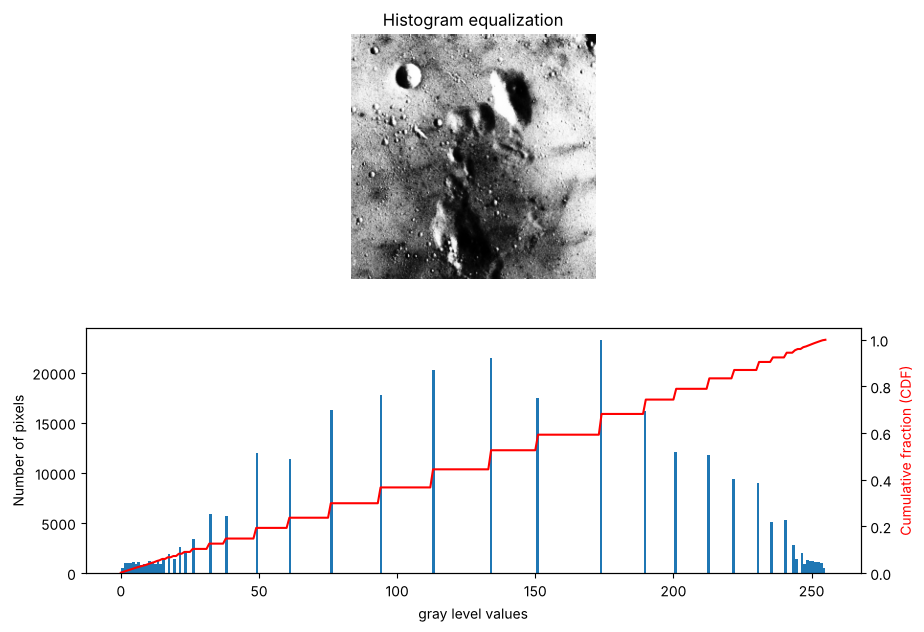

In [12]:
# Histogram equalization
img_eq = exposure.equalize_hist(img)      # float64 in [0, 1]
img_eq_u8 = img_as_ubyte(img_eq)          # back to uint8 [0, 255]

print('equalize_hist output:', img_eq.dtype, f'range [{img_eq.min():.4f}, {img_eq.max():.4f}]')
print(f'mean: {img.mean():.1f} -> {img_eq_u8.mean():.1f} | std: {img.std():.1f} -> {img_eq_u8.std():.1f}')
print(f'distinct gray levels: {len(np.unique(img))} -> {len(np.unique(img_eq_u8))}')

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq_u8, cmap='gray')
plt.axis('off')
plt.title('Histogram equalization')
ax = fig.add_subplot(2, 1, 2)
ax.hist(img_eq_u8.flat, bins=256, range=(0, 255))
ax.set_xlabel('gray level values')
ax.set_ylabel('Number of pixels')
# Cumulative distribution (CDF) of the equalized image - close to a straight line
ax_cdf = ax.twinx()
cdf, bin_centers = exposure.cumulative_distribution(img_eq_u8)
ax_cdf.plot(bin_centers, cdf, 'r', linewidth=1.5)
ax_cdf.set_ylabel('Cumulative fraction (CDF)', color='r')
ax_cdf.set_ylim(0, 1.05)
plt.savefig(os.path.join(OUT_DIR, 'B2_histogram_equalization.png'), dpi=110, bbox_inches='tight')
plt.show()

**Comparison:** histogram and CDF before and after equalization.

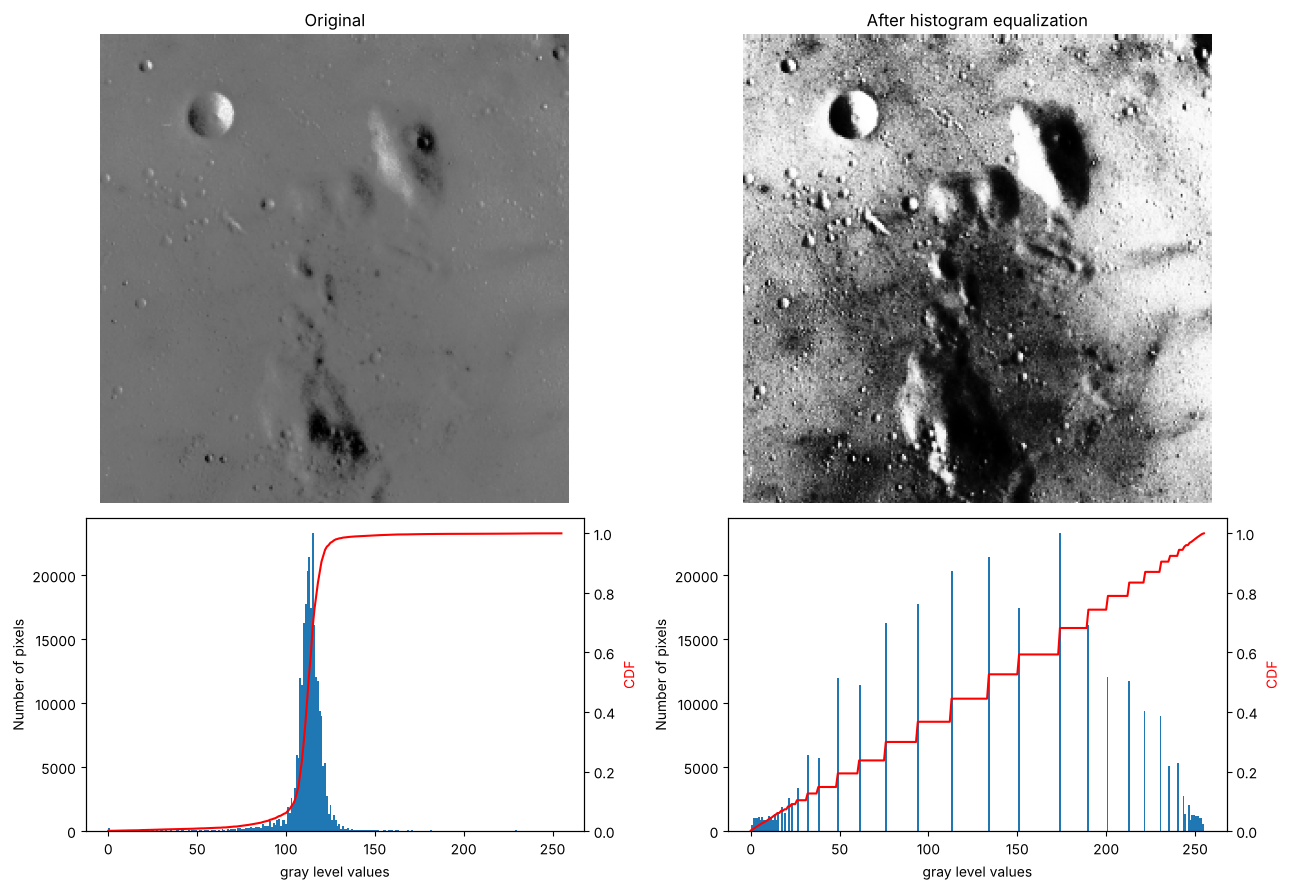

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), gridspec_kw={'height_ratios': [3, 2]})
for i, (im, title) in enumerate([(img, 'Original'), (img_eq_u8, 'After histogram equalization')]):
    axes[0, i].imshow(im, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(title)
    axes[0, i].axis('off')
    axes[1, i].hist(im.flat, bins=256, range=(0, 255))
    axes[1, i].set_xlabel('gray level values')
    axes[1, i].set_ylabel('Number of pixels')
    tw = axes[1, i].twinx()
    c, b = exposure.cumulative_distribution(im)
    tw.plot(b, c, 'r', linewidth=1.5)
    tw.set_ylim(0, 1.05)
    tw.set_ylabel('CDF', color='r')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'B2_comparison.png'), dpi=110, bbox_inches='tight')
plt.show()

### Observations – Assessment Task 2 (Histogram equalization)
- `equalize_hist` returns a float image in [0, 1]; it was converted to 8-bit so the histogram uses the same 0–255 axis.
- Before equalization the CDF is a steep S-curve (almost all of the change happens between about 100 and 125). After equalization the CDF is close to a **straight line from 0 to 1**, which means the histogram has been **flattened** and the pixels are spread over the whole 0–255 range.
- The histogram is not perfectly flat: with discrete gray levels, all pixels with the same input value must map to the same output value, so a heavily populated level cannot be split. The result is a set of isolated bars whose spacing grows where the original histogram was dense; rarely used levels in the tails merge together (178 → 49 distinct levels).
- Equalization gives the **largest contrast increase** of all methods in this lab (standard deviation 13.3 → 73.9, mean 112 → 134): surface texture and craters are very visible, but noise and grain are also amplified and the image looks harsher than with contrast stretching.
- Unlike contrast stretching (linear, needs chosen limits), equalization is a **non-linear, automatic** transformation that needs no parameters.

## Assessment Task 3: Histogram matching
Use the **rocket** image (reference) and the **Chelsea** image (source) from `skimage.data` and implement histogram
matching.

Histogram matching (specification) transforms the source image so that its CDF matches the CDF of the reference
image: for each gray level $r$ of the source, find the level $z$ with $G(z) \approx T(r)$, where $T$ is the source CDF
and $G$ is the reference CDF, i.e. $z = G^{-1}(T(r))$. For colour images this is done **independently for each
channel** (`channel_axis=-1`).

source   : (300, 451, 3) uint8
reference: (427, 640, 3) uint8
matched  : (300, 451, 3) uint8


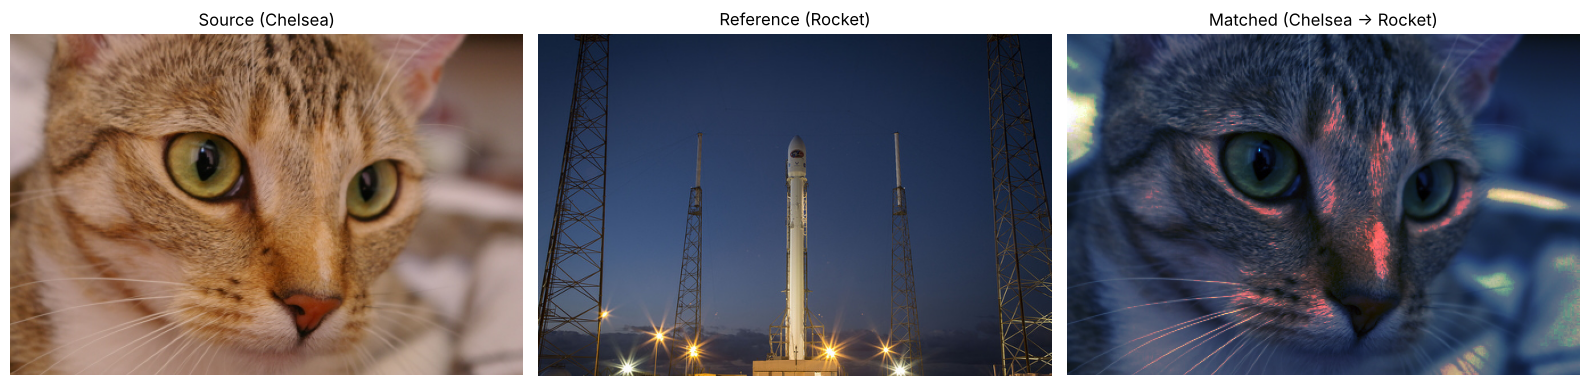

In [14]:
reference = data.rocket()     # reference image
image = data.chelsea()        # source image

# channel_axis=-1 -> match each RGB channel separately
# (for scikit-image older than 0.19 use: multichannel=True)
matched = exposure.match_histograms(image, reference, channel_axis=-1)
# some scikit-image versions return float64 values in 0-255 -> make sure the result is uint8
matched = np.clip(matched, 0, 255).astype(np.uint8)

print('source   :', image.shape, image.dtype)
print('reference:', reference.shape, reference.dtype)
print('matched  :', matched.shape, matched.dtype)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, im, title in zip(axes, (image, reference, matched),
                         ('Source (Chelsea)', 'Reference (Rocket)', 'Matched (Chelsea -> Rocket)')):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'B3_histogram_matching_images.png'), dpi=110, bbox_inches='tight')
plt.show()

**Histograms (bars) and cumulative histograms (black line) of each RGB channel** for the source, the reference and the
matched image:

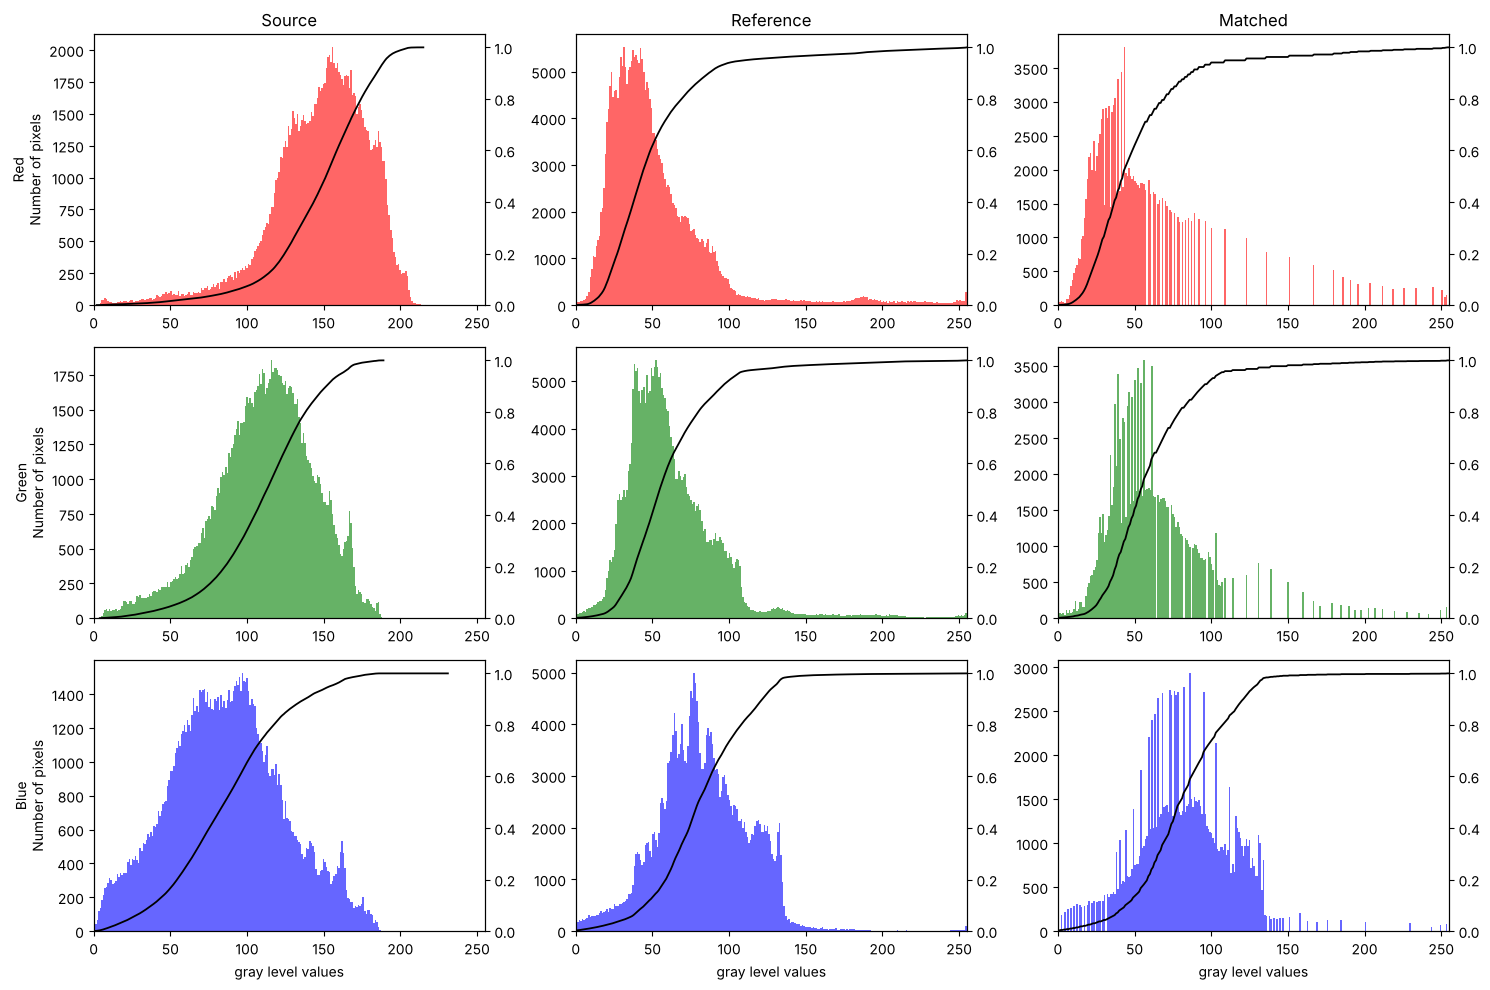

In [15]:
channels = ('Red', 'Green', 'Blue')
colors = ('red', 'green', 'blue')
images = ((image, 'Source'), (reference, 'Reference'), (matched, 'Matched'))

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for c, (ch, col) in enumerate(zip(channels, colors)):
    for i, (im, name) in enumerate(images):
        ax = axes[c, i]
        ax.hist(im[..., c].ravel(), bins=256, range=(0, 255), color=col, alpha=0.6)
        ax.set_xlim(0, 255)
        tw = ax.twinx()
        cdf, bins = exposure.cumulative_distribution(im[..., c])
        tw.plot(bins, cdf, 'k', linewidth=1.3)
        tw.set_ylim(0, 1.05)
        if c == 0:
            ax.set_title(name)
        if i == 0:
            ax.set_ylabel(f'{ch}\nNumber of pixels')
        if c == 2:
            ax.set_xlabel('gray level values')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'B3_histograms_per_channel.png'), dpi=110, bbox_inches='tight')
plt.show()

**Verification:** overlay the CDFs of the source, reference and matched image for each channel. If the matching
works, the matched CDF lies on top of the reference CDF.

Channel    mean |CDF_src - CDF_ref|   mean |CDF_matched - CDF_ref|
Red                          0.3757                         0.0033
Green                        0.1989                         0.0028
Blue                         0.0301                         0.0024


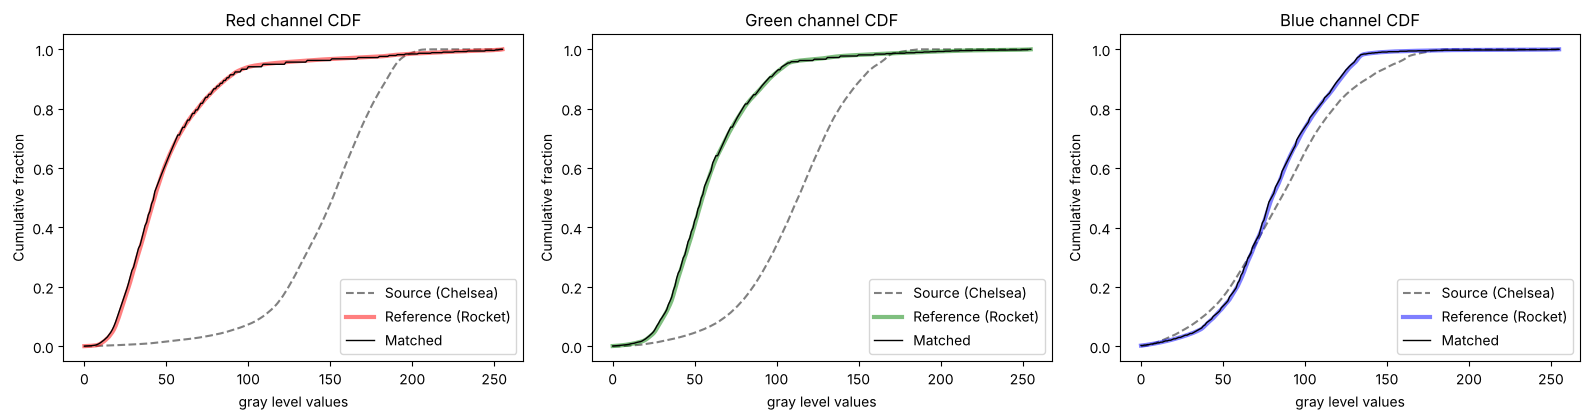


Channel   mean source  mean reference  mean matched
Red             147.7            52.3          52.1
Green           111.4            61.3          60.8
Blue             86.8            82.3          81.7


In [16]:
def cdf_256(channel):
    hist, _ = np.histogram(channel, bins=256, range=(0, 256))
    return np.cumsum(hist) / hist.sum()

levels = np.arange(256)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
print(f"{'Channel':8s} {'mean |CDF_src - CDF_ref|':>26s} {'mean |CDF_matched - CDF_ref|':>30s}")
for c, (ch, col) in enumerate(zip(channels, colors)):
    cdf_src, cdf_ref, cdf_mat = (cdf_256(im[..., c]) for im in (image, reference, matched))
    axes[c].plot(levels, cdf_src, color='gray', linestyle='--', label='Source (Chelsea)')
    axes[c].plot(levels, cdf_ref, color=col, linewidth=3, alpha=0.5, label='Reference (Rocket)')
    axes[c].plot(levels, cdf_mat, color='k', linewidth=1, label='Matched')
    axes[c].set_title(f'{ch} channel CDF')
    axes[c].set_xlabel('gray level values')
    axes[c].set_ylabel('Cumulative fraction')
    axes[c].legend(loc='lower right')
    print(f'{ch:8s} {np.abs(cdf_src - cdf_ref).mean():26.4f} {np.abs(cdf_mat - cdf_ref).mean():30.4f}')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'B3_cdf_verification.png'), dpi=110, bbox_inches='tight')
plt.show()

print()
print(f"{'Channel':8s} {'mean source':>12s} {'mean reference':>15s} {'mean matched':>13s}")
for c, ch in enumerate(channels):
    print(f'{ch:8s} {image[..., c].mean():12.1f} {reference[..., c].mean():15.1f} {matched[..., c].mean():13.1f}')

### Observations – Assessment Task 3 (Histogram matching)
- Chelsea is a warm image dominated by orange/brown tones (high red values), while the rocket is a dark blue night scene (low red and green, relatively higher blue).
- After matching, the cat takes on the **colour palette and brightness of the rocket image**: the channel means move almost exactly to the reference values (Red 147.7 → 52.1, reference 52.3; Green 111.4 → 60.8, reference 61.3; Blue 86.8 → 81.7, reference 82.3).
- **Verification:** the mean absolute difference between the CDF of each channel and the reference CDF drops from 0.376 / 0.199 / 0.030 (R/G/B) to about **0.003** for every channel – the matched CDFs lie on top of the reference CDFs.
- The matched histograms follow the shape of the reference histograms but contain gaps and spikes, because the mapping is applied to discrete gray levels.
- Some **pink/red patches** appear on the brightest fur. The rocket image contains a small number of very bright red pixels (the launch-pad lights), so Chelsea's brightest red values are mapped to very high red values. Because each channel is matched independently, the relationship between the R, G and B channels is not preserved, which produces these unnatural colours.
- The structure of the image (edges, shapes, whiskers) does not change: histogram matching is a point operation that only changes the intensity/colour distribution.

## Conclusion
In this lab several **intensity transformations in the spatial domain** were implemented. In all of them, each output pixel depends only on the value of the corresponding input pixel:

| Method | Type | Parameters | Main effect / limitation |
|---|---|---|---|
| Thresholding | Binary point operation | threshold *T* | Simple segmentation into foreground/background; the result is very sensitive to *T* |
| Contrast stretching (2nd–98th) | Linear | percentiles | Balanced contrast enhancement with about 2 % clipping at each end |
| Contrast stretching (3rd–80th) | Linear | percentiles | Stronger contrast in dark/mid tones, but 21 % of the pixels saturate to white |
| Histogram equalization | Non-linear, automatic | none | Flattens the histogram (linear CDF); largest contrast gain but also amplifies noise |
| Histogram matching | Non-linear | reference image | Gives the source the histogram (and colour mood) of the reference; channel-wise matching can create colour artefacts |

Histogram equalization is a special case of histogram matching in which the target histogram is uniform. None of these transformations can create new gray levels; they only redistribute the existing ones, which is why the processed histograms show gaps.

In [17]:
print('Images used   :', sorted(os.listdir(IMG_DIR)))
print('Saved figures :', sorted(os.listdir(OUT_DIR)))

Images used   : ['Parrot.png', 'chelsea.png', 'moon.png', 'rocket.png']
Saved figures : ['A1_parrot_histogram.png', 'A1_thresholding.png', 'A2_moon_contrast_stretch_2_98.png', 'A2_moon_original.png', 'B1_comparison.png', 'B1_contrast_stretch_3_80.png', 'B2_comparison.png', 'B2_histogram_equalization.png', 'B3_cdf_verification.png', 'B3_histogram_matching_images.png', 'B3_histograms_per_channel.png']


## References
- S. Dey, *Hands-On Image Processing with Python*, Packt Publishing, 2018.
- scikit-image: Histogram Equalization – https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_equalize.html
- scikit-image: Histogram matching – https://scikit-image.org/docs/0.24.x/auto_examples/color_exposure/plot_histogram_matching.html
- OpenCV: Image Thresholding – https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html